# Tesla Stock Price Prediction using SimpleRNN and LSTM

**Domain:** Financial Services

**Problem Statement:**  
Develop deep learning models (SimpleRNN and LSTM) to predict Tesla's
closing stock price 1-day, 5-day and 10-day ahead, and compare their
performance.

## Project Objectives

- Analyze and preprocess Tesla stock price data.
- Perform exploratory data analysis and visualization.
- Build SimpleRNN and LSTM models.
- Predict 1-day, 5-day and 10-day stock prices.
- Evaluate models using MSE, RMSE and MAE.
- Tune LSTM hyperparameters using GridSearchCV.
- Compare SimpleRNN and LSTM performance.
- Analyze limitations and future improvements.

## Section 1: Import Libraries & Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, SimpleRNN, LSTM
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

plt.style.use('seaborn-v0_8-darkgrid')
tf.random.set_seed(42)
np.random.seed(42)

print("All libraries imported successfully")

All libraries imported successfully


## Section 2: Load Dataset

In [2]:
candidate_paths = ["TSLA.csv", "/mnt/user-data/uploads/TSLA.csv"]
csv_path = next((p for p in candidate_paths if os.path.exists(p)), candidate_paths[0])

df = pd.read_csv(csv_path)
print(f"Dataset loaded successfully from: {csv_path}")
df.head()

Dataset loaded successfully from: TSLA.csv


,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


In [3]:
df.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
2411,2020-01-28,568.489990,576.809998,558.080017,566.900024,566.900024,11788500
2412,2020-01-29,575.690002,589.799988,567.429993,580.989990,580.989990,17801500
2413,2020-01-30,632.419983,650.880005,618.000000,640.809998,640.809998,29005700
2414,2020-01-31,640.000000,653.000000,632.520020,650.570007,650.570007,15719300
2415,2020-02-03,673.690002,786.140015,673.520020,780.000000,780.000000,47065000


## Section 3: Data Understanding

In [4]:
print("Dataset Shape:", df.shape)
df.info()

Dataset Shape: (2416, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2416 non-null   object 
 1   Open       2416 non-null   float64
 2   High       2416 non-null   float64
 3   Low        2416 non-null   float64
 4   Close      2416 non-null   float64
 5   Adj Close  2416 non-null   float64
 6   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 132.3+ KB


In [5]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2416.000000,2416.000000,2416.000000,2416.000000,2416.000000,2.416000e+03
mean,186.271147,189.578224,182.916639,186.403651,186.403651,5.572722e+06
std,118.740163,120.892329,116.857591,119.136020,119.136020,4.987809e+06
min,16.139999,16.629999,14.980000,15.800000,15.800000,1.185000e+05
25%,34.342498,34.897501,33.587501,34.400002,34.400002,1.899275e+06
50%,213.035004,216.745002,208.870002,212.960007,212.960007,4.578400e+06
75%,266.450012,270.927513,262.102501,266.774994,266.774994,7.361150e+06
max,673.690002,786.140015,673.520020,780.000000,780.000000,4.706500e+07


## Section 4: Data Cleaning

In [6]:
print("Missing Values:\n", df.isnull().sum())
print("\nDuplicate Records:", df.duplicated().sum())

Missing Values:
 Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Duplicate Records: 0


In [7]:
# Demonstrate the missing-value strategy on a simulated copy (real data has no gaps)
rng = np.random.RandomState(42)
demo = df.copy()
sim_idx = rng.choice(demo.index[20:-20], size=15, replace=False)
demo.loc[sim_idx, 'Adj Close'] = np.nan
print("Simulated NaNs:", demo['Adj Close'].isnull().sum())

demo['Adj Close'] = demo['Adj Close'].ffill().interpolate(method='linear')
print("After ffill + interpolate:", demo['Adj Close'].isnull().sum())

Simulated NaNs: 15
After ffill + interpolate: 0


In [8]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)
print(df["Date"].dtype)

datetime64[ns]


In [9]:
df.set_index("Date", inplace=True)
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


## Section 5: Exploratory Data Analysis (EDA)

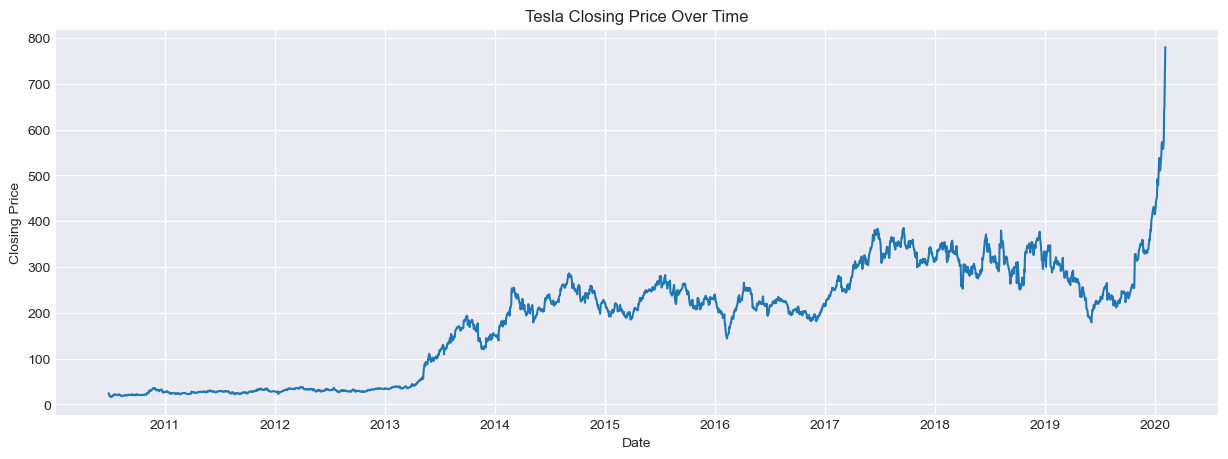

In [10]:
plt.figure(figsize=(15,5))
plt.plot(df["Close"])
plt.title("Tesla Closing Price Over Time")
plt.xlabel("Date"); plt.ylabel("Closing Price"); plt.grid(True)
plt.show()

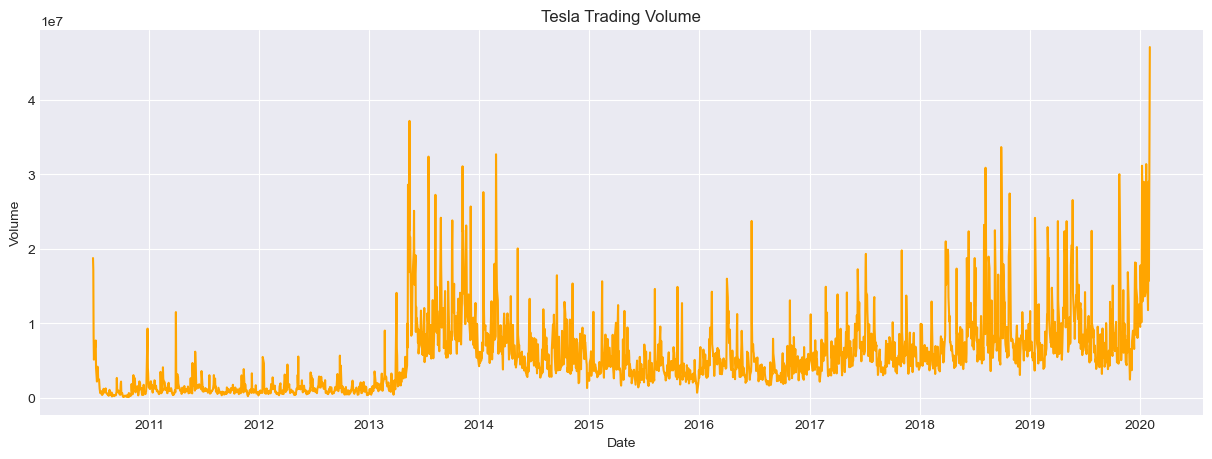

In [11]:
plt.figure(figsize=(15,5))
plt.plot(df["Volume"], color="orange")
plt.title("Tesla Trading Volume")
plt.xlabel("Date"); plt.ylabel("Volume"); plt.grid(True)
plt.show()

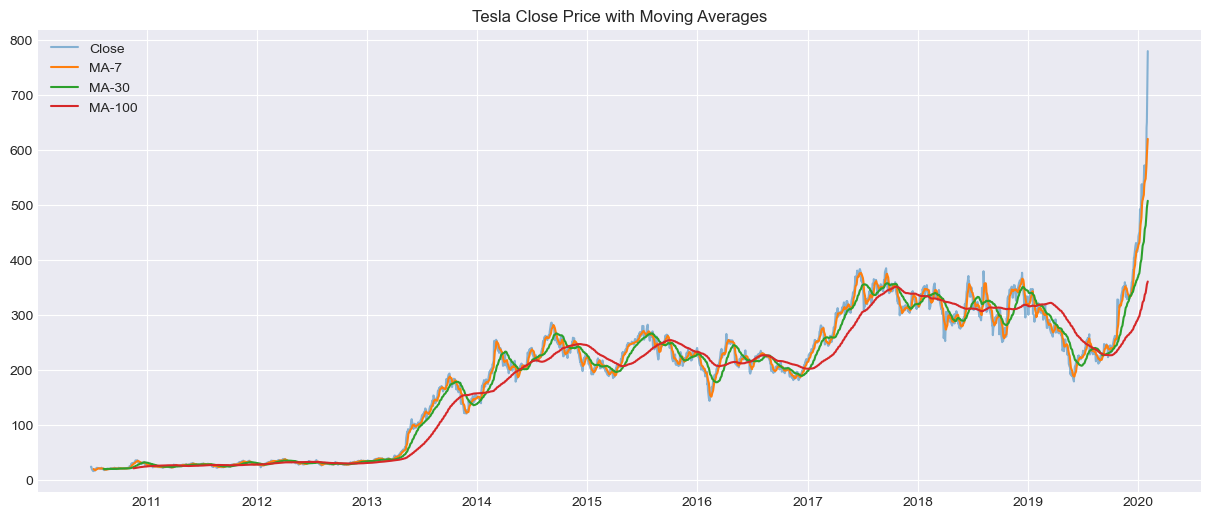

In [12]:
df["MA7"] = df["Close"].rolling(7).mean()
df["MA30"] = df["Close"].rolling(30).mean()
df["MA100"] = df["Close"].rolling(100).mean()

plt.figure(figsize=(15,6))
plt.plot(df["Close"], label="Close", alpha=0.5)
plt.plot(df["MA7"], label="MA-7")
plt.plot(df["MA30"], label="MA-30")
plt.plot(df["MA100"], label="MA-100")
plt.title("Tesla Close Price with Moving Averages")
plt.legend(); plt.show()


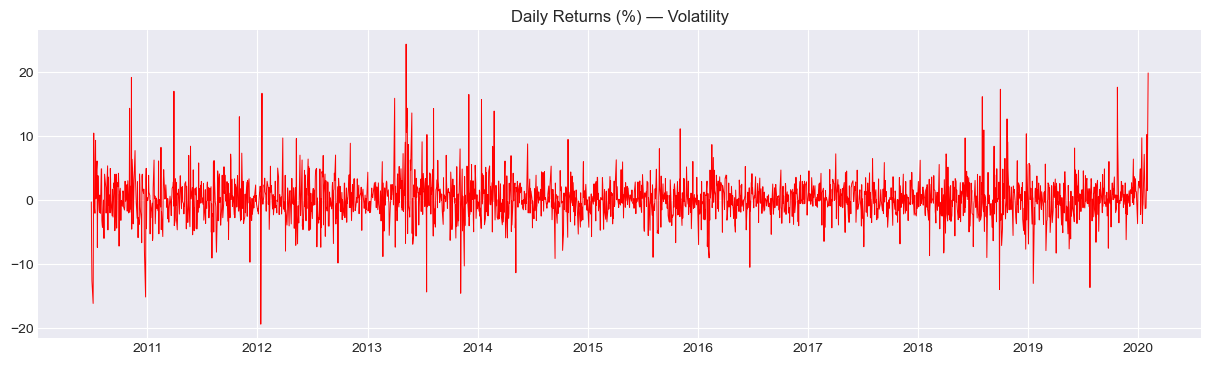

In [13]:
df["Daily_Return"] = df["Close"].pct_change() * 100
plt.figure(figsize=(15,4))
plt.plot(df["Daily_Return"], color="red", linewidth=0.7)
plt.title("Daily Returns (%) — Volatility")
plt.show()


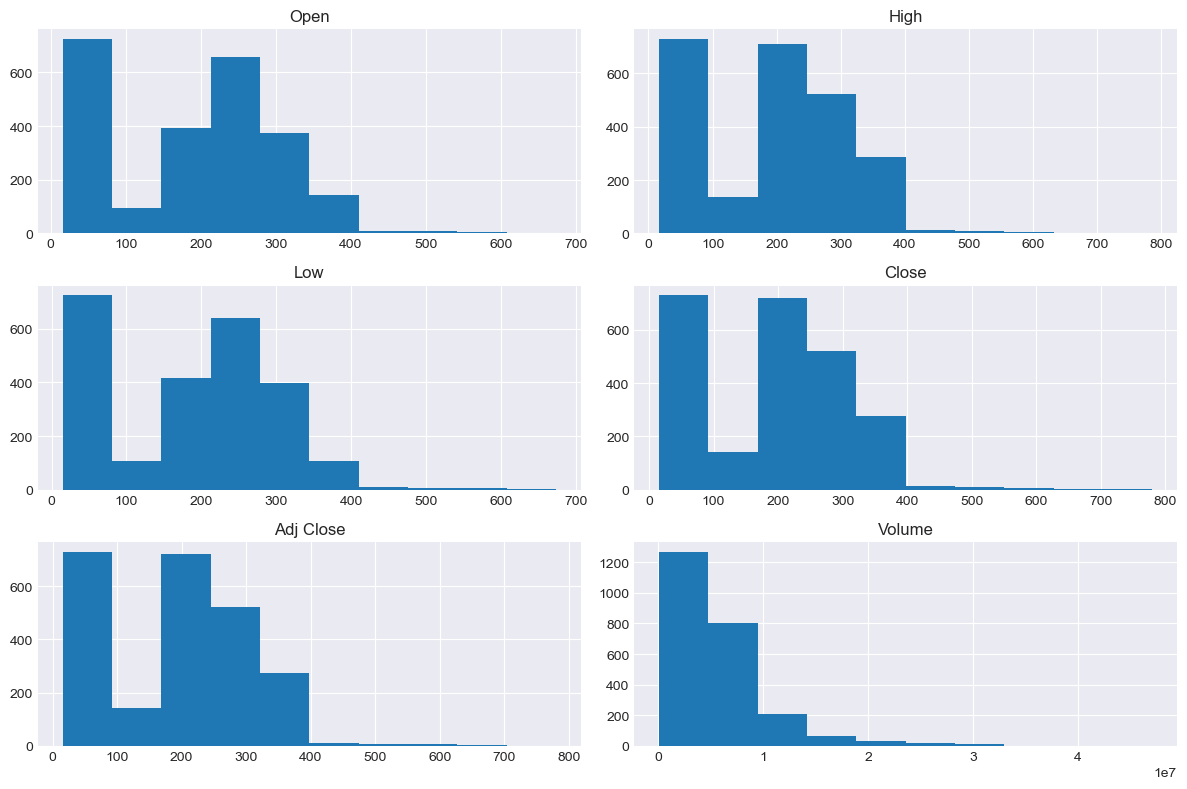

In [14]:
df[["Open","High","Low","Close","Adj Close","Volume"]].hist(figsize=(12,8))
plt.tight_layout(); plt.show()

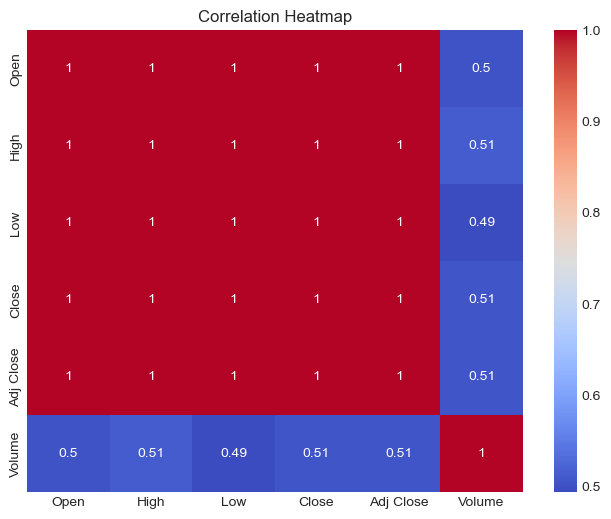

In [15]:
plt.figure(figsize=(8,6))
sns.heatmap(df[["Open","High","Low","Close","Adj Close","Volume"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

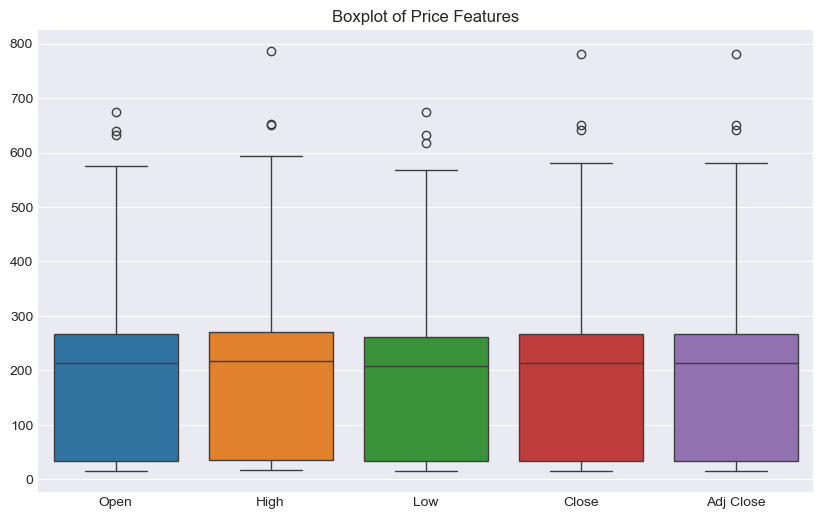

In [16]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df[["Open","High","Low","Close","Adj Close"]])
plt.title("Boxplot of Price Features")
plt.show()

## Section 6: Feature Engineering & Target Selection

In [17]:
data = df[["Adj Close"]]
print("Shape of selected data:", data.shape)
data.head()

Shape of selected data: (2416, 1)


,Adj Close
Date,
2010-06-29,23.889999
2010-06-30,23.830000
2010-07-01,21.959999
2010-07-02,19.200001
2010-07-06,16.110001


## Section 7: Data Scaling

In [18]:
SPLIT_RATIO = 0.8
split_point = int(len(data) * SPLIT_RATIO)
print("Split date:", df.index[split_point].date())

train_raw = data.values[:split_point]
test_raw  = data.values[split_point:]

scaler = MinMaxScaler(feature_range=(0,1))
scaler.fit(train_raw)                      # fit on TRAIN ONLY
train_scaled = scaler.transform(train_raw)
test_scaled  = scaler.transform(test_raw)

print("Train size:", len(train_raw), " Test size:", len(test_raw))

Split date: 2018-03-02
Train size: 1932  Test size: 484


## Section 8: Time-Series Sequence Creation (per forecast horizon)

In [19]:
WINDOW = 60
HORIZONS = [1, 5, 10]


def create_sequences(scaled_series, window, horizon):

    X, y = [], []

    for i in range(len(scaled_series) - window - horizon + 1):

        X.append(scaled_series[i:i+window, 0])

        y.append(
            scaled_series[i+window+horizon-1, 0]
        )

    X = np.array(X)
    y = np.array(y)

    return X.reshape(X.shape[0], X.shape[1], 1), y


datasets = {}

for h in HORIZONS:

    # --------------------------------------------------------
    # Training sequences
    # --------------------------------------------------------

    X_train, y_train = create_sequences(
        train_scaled,
        WINDOW,
        h
    )

    # --------------------------------------------------------
    # Test sequences
    # Use last WINDOW training observations as history
    # --------------------------------------------------------

    test_input = np.concatenate(
        [train_scaled[-WINDOW:], test_scaled],
        axis=0
    )

    X_test, y_test = create_sequences(
        test_input,
        WINDOW,
        h
    )

    datasets[h] = {
        "X_train": X_train,
        "y_train": y_train,
        "X_test": X_test,
        "y_test": y_test
    }

    print(
        f"Horizon {h}d -> "
        f"X_train {X_train.shape}, "
        f"X_test {X_test.shape}"
    )

Horizon 1d -> X_train (1872, 60, 1), X_test (484, 60, 1)
Horizon 5d -> X_train (1868, 60, 1), X_test (480, 60, 1)
Horizon 10d -> X_train (1863, 60, 1), X_test (475, 60, 1)


## Section 9: Sequence Summary

In [20]:
## Section 9: Train-Test Split Summary

summary = pd.DataFrame([
    {
        "Horizon": h,
        "X_train": str(datasets[h]["X_train"].shape),
        "X_test": str(datasets[h]["X_test"].shape)
    }
    for h in HORIZONS
])

summary

,Horizon,X_train,X_test
0,1,"(1872, 60, 1)","(484, 60, 1)"
1,5,"(1868, 60, 1)","(480, 60, 1)"
2,10,"(1863, 60, 1)","(475, 60, 1)"


## Section 10: Model Architectures — SimpleRNN & LSTM

In [21]:
def build_simplernn(window=WINDOW, units=64, dropout=0.2, learning_rate=0.001):
    model = Sequential([
        SimpleRNN(units, return_sequences=True, input_shape=(window, 1)),
        Dropout(dropout),
        SimpleRNN(max(units//2, 8)),
        Dropout(dropout),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss="mean_squared_error")
    return model

def build_lstm(window=WINDOW, units=64, dropout=0.2, learning_rate=0.001):
    model = Sequential([
        LSTM(units, return_sequences=True, input_shape=(window, 1)),
        Dropout(dropout),
        LSTM(max(units//2, 8)),
        Dropout(dropout),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss="mean_squared_error")
    return model

build_simplernn().summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 60, 64)              │           4,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_1 (SimpleRNN)             │ (None, 32)                  │           3,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,361 (28.75 KB)

 Trainable params: 7,361 (28.75 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
build_lstm().summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 64)              │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 60, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

## Section 11: Training — SimpleRNN & LSTM for all 3 horizons

In [23]:
results = {}
histories = {}

for h in HORIZONS:
    Xtr, ytr = datasets[h]['X_train'], datasets[h]['y_train']
    Xte, yte = datasets[h]['X_test'], datasets[h]['y_test']

    for arch, builder in [("SimpleRNN", build_simplernn), ("LSTM", build_lstm)]:
        print(f"\n{'='*55}\nTraining {arch} | horizon={h}d\n{'='*55}")
        model = builder(WINDOW)
        ckpt = f"best_{arch}_h{h}.keras"
        cbs = [
            EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
            ModelCheckpoint(ckpt, monitor="val_loss", save_best_only=True)
        ]
        hist = model.fit(Xtr, ytr, validation_split=0.1, epochs=50,
                          batch_size=32, callbacks=cbs, verbose=0)
        test_mse_scaled = model.evaluate(Xte, yte, verbose=0)
        print(f"{arch} h={h}d -> epochs run: {len(hist.history['loss'])}, "
              f"final val_loss: {hist.history['val_loss'][-1]:.6f}, "
              f"test loss (scaled): {test_mse_scaled:.6f}")
        key = f"{arch}_h{h}"
        results[key] = dict(model_path=ckpt, arch=arch, horizon=h)
        histories[key] = hist.history

print("\nAll 6 models trained (SimpleRNN & LSTM x 1/5/10-day horizons).")


Training SimpleRNN | horizon=1d
SimpleRNN h=1d -> epochs run: 23, final val_loss: 0.001800, test loss (scaled): 0.004014

Training LSTM | horizon=1d
LSTM h=1d -> epochs run: 29, final val_loss: 0.001599, test loss (scaled): 0.004246

Training SimpleRNN | horizon=5d
SimpleRNN h=5d -> epochs run: 32, final val_loss: 0.003418, test loss (scaled): 0.006541

Training LSTM | horizon=5d
LSTM h=5d -> epochs run: 15, final val_loss: 0.005061, test loss (scaled): 0.010457

Training SimpleRNN | horizon=10d
SimpleRNN h=10d -> epochs run: 9, final val_loss: 0.005853, test loss (scaled): 0.020412

Training LSTM | horizon=10d
LSTM h=10d -> epochs run: 10, final val_loss: 0.009099, test loss (scaled): 0.015891

All 6 models trained (SimpleRNN & LSTM x 1/5/10-day horizons).


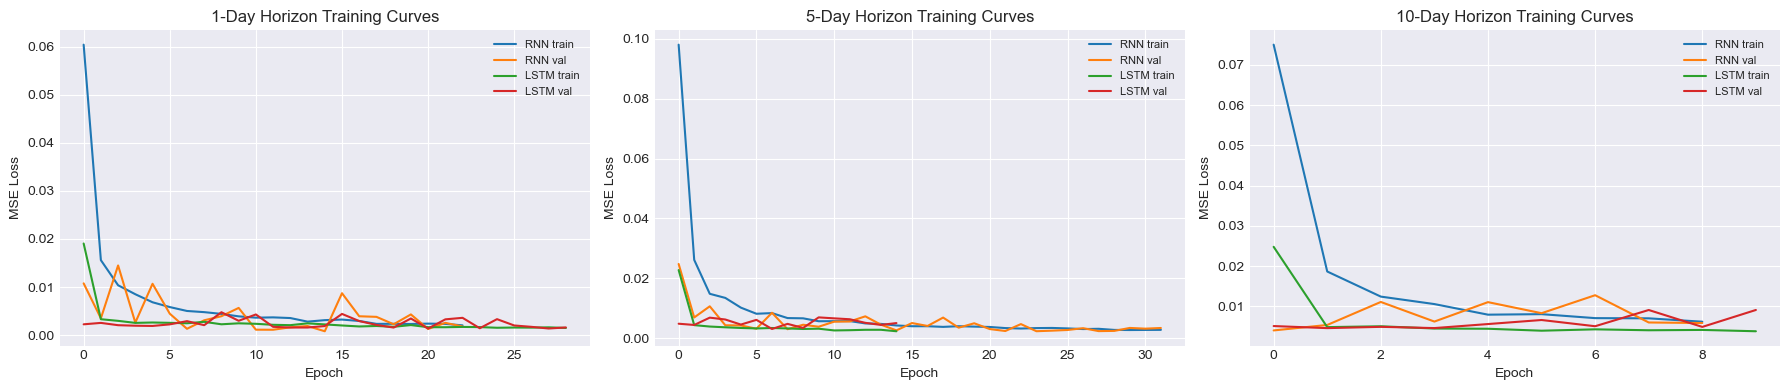

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18,4))
for ax, h in zip(axes, HORIZONS):
    ax.plot(histories[f"SimpleRNN_h{h}"]["loss"], label="RNN train")
    ax.plot(histories[f"SimpleRNN_h{h}"]["val_loss"], label="RNN val")
    ax.plot(histories[f"LSTM_h{h}"]["loss"], label="LSTM train")
    ax.plot(histories[f"LSTM_h{h}"]["val_loss"], label="LSTM val")
    ax.set_title(f"{h}-Day Horizon Training Curves")
    ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Section 12: Evaluation — MSE / RMSE / MAE per model per horizon

In [25]:
eval_rows = []
predictions_store = {}
for h in HORIZONS:
    Xte, yte = datasets[h]['X_test'], datasets[h]['y_test']
    y_actual = scaler.inverse_transform(yte.reshape(-1,1))
    for arch in ["SimpleRNN", "LSTM"]:
        key = f"{arch}_h{h}"
        model = load_model(results[key]['model_path'])
        pred_scaled = model.predict(Xte, verbose=0)
        pred = scaler.inverse_transform(pred_scaled)
        mse = mean_squared_error(y_actual, pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_actual, pred)
        r2 = r2_score(y_actual, pred)          
        eval_rows.append({"Model": arch, "Horizon (days)": h, "MSE": mse, "RMSE": rmse, "MAE": mae, "R2 Score": r2})
        predictions_store[key] = dict(actual=y_actual, pred=pred)
comparison = pd.DataFrame(eval_rows).sort_values(["Horizon (days)", "Model"]).reset_index(drop=True)
comparison

,Model,Horizon (days),MSE,RMSE,MAE,R2 Score
0,LSTM,1,578.785879,24.057969,15.724200,0.887807
1,SimpleRNN,1,547.095840,23.390080,14.235297,0.893950
2,LSTM,5,1425.397644,37.754439,26.390878,0.725598
3,SimpleRNN,5,891.536157,29.858603,20.247420,0.828371
4,LSTM,10,2166.074650,46.541107,33.459266,0.586480
5,SimpleRNN,10,2782.325101,52.747750,37.560394,0.468833


## Section 13: Actual vs Predicted — visualizations per horizon

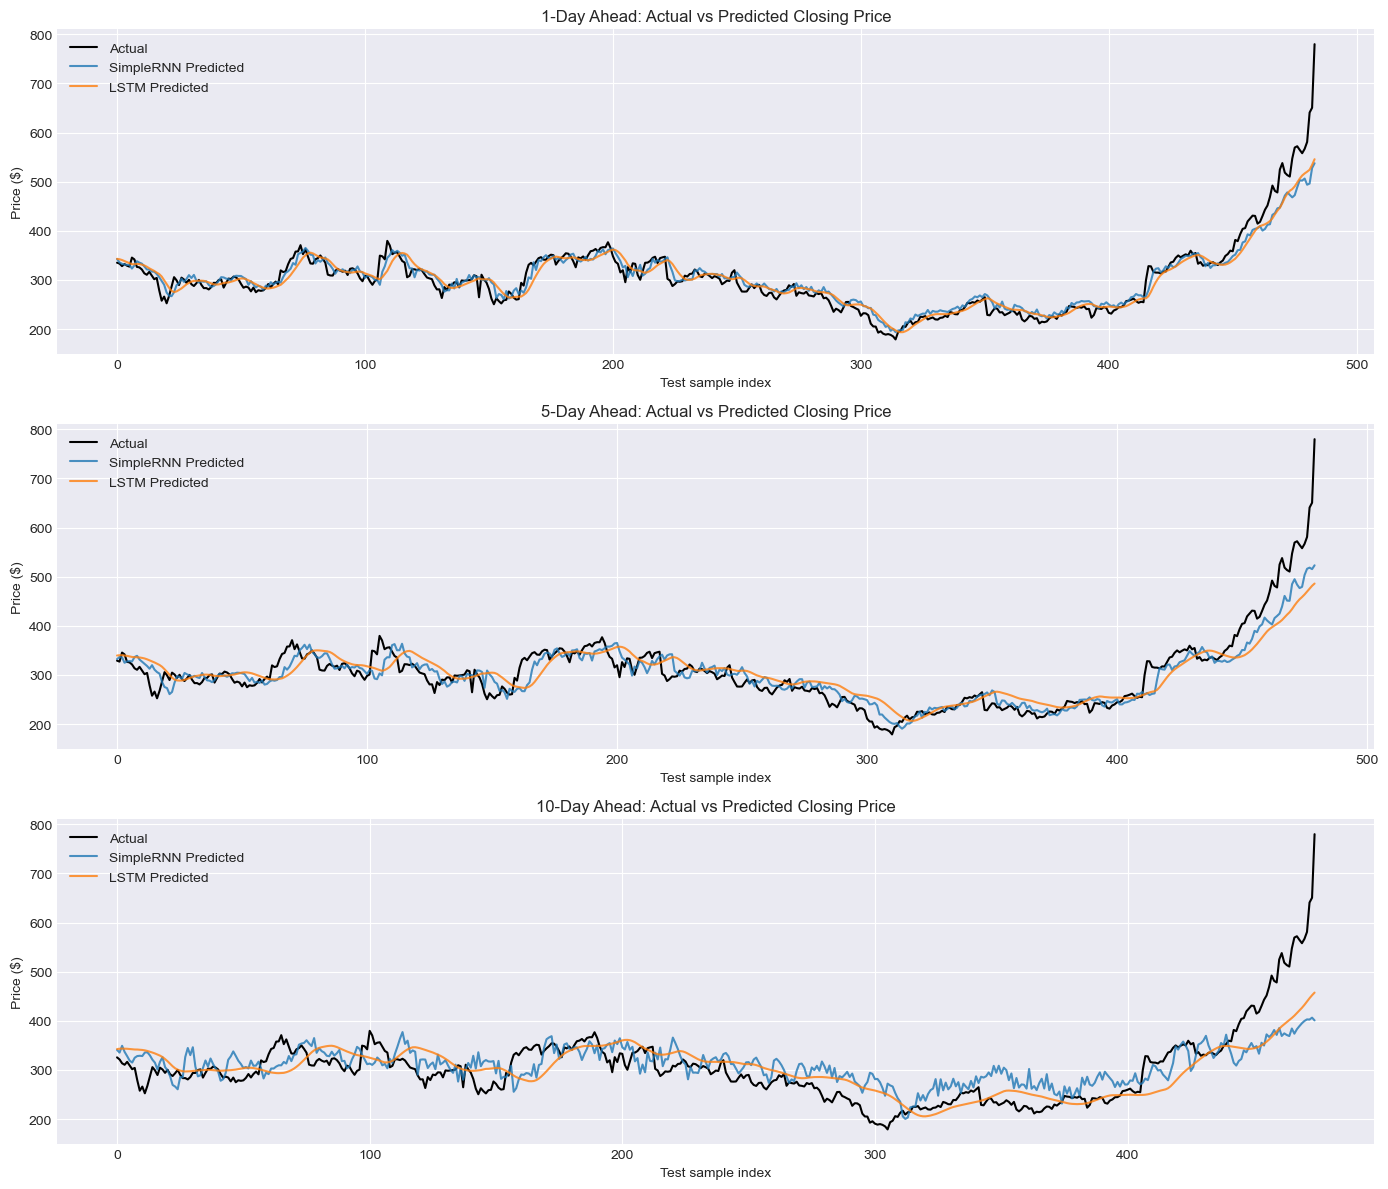

In [26]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
for ax, h in zip(axes, HORIZONS):
    ax.plot(predictions_store[f"SimpleRNN_h{h}"]["actual"], label="Actual", color="black", linewidth=1.5)
    ax.plot(predictions_store[f"SimpleRNN_h{h}"]["pred"], label="SimpleRNN Predicted", alpha=0.8)
    ax.plot(predictions_store[f"LSTM_h{h}"]["pred"], label="LSTM Predicted", alpha=0.8)
    ax.set_title(f"{h}-Day Ahead: Actual vs Predicted Closing Price")
    ax.set_xlabel("Test sample index"); ax.set_ylabel("Price ($)"); ax.legend()
plt.tight_layout(); plt.show()


## Section 14: Hyperparameter Tuning with GridSearchCV

In [28]:
# ============================================================
# Section 14: Hyperparameter Tuning with GridSearchCV
# SimpleRNN & LSTM | 1-day, 5-day, 10-day
# ============================================================

from scikeras.wrappers import KerasRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit


# ------------------------------------------------------------
# Wrapper functions for GridSearchCV
# ------------------------------------------------------------

def build_lstm_for_grid(units=64, dropout=0.2, learning_rate=0.001):
    return build_lstm(
        WINDOW,
        units=units,
        dropout=dropout,
        learning_rate=learning_rate
    )


def build_simplernn_for_grid(units=64, dropout=0.2, learning_rate=0.001):
    return build_simplernn(
        WINDOW,
        units=units,
        dropout=dropout,
        learning_rate=learning_rate
    )


# ------------------------------------------------------------
# Hyperparameter grid
# ------------------------------------------------------------

param_grid = {
    "model__units": [32, 64],
    "model__dropout": [0.2, 0.3],
    "model__learning_rate": [0.001, 0.005],
}

# Time-series-safe cross-validation
tscv = TimeSeriesSplit(n_splits=2)


# ------------------------------------------------------------
# Models to tune
# ------------------------------------------------------------

builders = {
    "LSTM": build_lstm_for_grid,
    "SimpleRNN": build_simplernn_for_grid
}


# ------------------------------------------------------------
# Store tuning results
# ------------------------------------------------------------

tuning_results = {}


# ------------------------------------------------------------
# GridSearchCV for both models and all horizons
# ------------------------------------------------------------

for arch, build_fn in builders.items():

    for h in HORIZONS:

        print(f"\n{'='*60}")
        print(f"GridSearchCV: {arch} | Horizon = {h} days")
        print(f"{'='*60}")

        Xtr = datasets[h]["X_train"]
        ytr = datasets[h]["y_train"]

        Xte = datasets[h]["X_test"]
        yte = datasets[h]["y_test"]


        # Keras model wrapper
        reg = KerasRegressor(
            model=build_fn,
            verbose=0,
            epochs=8,
            batch_size=32
        )


        # ----------------------------------------------------
        # GridSearchCV
        # ----------------------------------------------------

        grid = GridSearchCV(
            estimator=reg,
            param_grid=param_grid,
            scoring="neg_mean_squared_error",
            cv=tscv,
            n_jobs=1
        )


        # Run GridSearch
        grid_result = grid.fit(Xtr, ytr)


        # ----------------------------------------------------
        # Best parameters
        # ----------------------------------------------------

        best_params = {
            k.replace("model__", ""): v
            for k, v in grid_result.best_params_.items()
        }

        print("Best Parameters:", best_params)

        print(
            "Best CV Score (negative MSE):",
            grid_result.best_score_
        )


        # ----------------------------------------------------
        # Retrain model using best parameters
        # ----------------------------------------------------

        if arch == "LSTM":

            tuned_model = build_lstm(
                WINDOW,
                **best_params
            )

        else:

            tuned_model = build_simplernn(
                WINDOW,
                **best_params
            )


        callbacks = [

            EarlyStopping(
                monitor="val_loss",
                patience=8,
                restore_best_weights=True
            ),

            ModelCheckpoint(
                f"best_{arch}_h{h}_tuned.keras",
                monitor="val_loss",
                save_best_only=True
            )

        ]


        tuned_model.fit(
            Xtr,
            ytr,
            validation_split=0.1,
            epochs=50,
            batch_size=32,
            callbacks=callbacks,
            verbose=0
        )


        # ----------------------------------------------------
        # Prediction on held-out test data
        # ----------------------------------------------------

        y_actual = scaler.inverse_transform(
            yte.reshape(-1, 1)
        )

        pred_scaled = tuned_model.predict(
            Xte,
            verbose=0
        )

        pred = scaler.inverse_transform(
            pred_scaled
        )


        # ----------------------------------------------------
        # Evaluation metrics
        # ----------------------------------------------------

        tuned_mse = mean_squared_error(
            y_actual,
            pred
        )

        tuned_rmse = np.sqrt(tuned_mse)

        tuned_mae = mean_absolute_error(
            y_actual,
            pred
        )

        tuned_r2 = r2_score(
            y_actual,
            pred
        )


        # ----------------------------------------------------
        # Compare with original baseline model
        # ----------------------------------------------------

        baseline_row = comparison[
            (comparison["Model"] == arch) &
            (comparison["Horizon (days)"] == h)
        ]

        baseline_rmse = baseline_row["RMSE"].values[0]

        improved = tuned_rmse < baseline_rmse


        print(f"\nTuned {arch} - {h} Day")
        print(f"MSE  : {tuned_mse:.4f}")
        print(f"RMSE : {tuned_rmse:.4f}")
        print(f"MAE  : {tuned_mae:.4f}")
        print(f"R²   : {tuned_r2:.4f}")

        print(f"Baseline RMSE : {baseline_rmse:.4f}")

        print(
            "Result:",
            "IMPROVED" if improved else "DID NOT IMPROVE"
        )


        # ----------------------------------------------------
        # Save results
        # ----------------------------------------------------

        tuning_results[f"{arch}_h{h}"] = {

            "Model": arch,

            "Horizon": h,

            "Best Parameters": best_params,

            "CV Score": grid_result.best_score_,

            "Tuned MSE": tuned_mse,

            "Tuned RMSE": tuned_rmse,

            "Tuned MAE": tuned_mae,

            "Tuned R2": tuned_r2,

            "Baseline RMSE": baseline_rmse,

            "Improved": improved
        }


print("\nAll 6 GridSearchCV tuning runs completed.")


# ============================================================
# Final Tuning Summary
# ============================================================

tuning_summary = pd.DataFrame(
    tuning_results.values()
)

tuning_summary = tuning_summary.sort_values(
    ["Horizon", "Model"]
).reset_index(drop=True)

tuning_summary


GridSearchCV: LSTM | Horizon = 1 days
Best Parameters: {'dropout': 0.2, 'learning_rate': 0.001, 'units': 64}
Best CV Score (negative MSE): -0.003563084565189797

Tuned LSTM - 1 Day
MSE  : 369.8234
RMSE : 19.2308
MAE  : 12.5719
R²   : 0.9283
Baseline RMSE : 24.0580
Result: IMPROVED

GridSearchCV: LSTM | Horizon = 5 days
Best Parameters: {'dropout': 0.3, 'learning_rate': 0.001, 'units': 64}
Best CV Score (negative MSE): -0.007884779083282488

Tuned LSTM - 5 Day
MSE  : 1365.6975
RMSE : 36.9553
MAE  : 24.7524
R²   : 0.7371
Baseline RMSE : 37.7544
Result: IMPROVED

GridSearchCV: LSTM | Horizon = 10 days
Best Parameters: {'dropout': 0.2, 'learning_rate': 0.001, 'units': 32}
Best CV Score (negative MSE): -0.01253749347495427

Tuned LSTM - 10 Day
MSE  : 2261.2437
RMSE : 47.5525
MAE  : 33.3636
R²   : 0.5683
Baseline RMSE : 46.5411
Result: DID NOT IMPROVE

GridSearchCV: SimpleRNN | Horizon = 1 days
Best Parameters: {'dropout': 0.2, 'learning_rate': 0.005, 'units': 64}
Best CV Score (negative MS

,Model,Horizon,Best Parameters,CV Score,Tuned MSE,Tuned RMSE,Tuned MAE,Tuned R2,Baseline RMSE,Improved
0,LSTM,1,"{'dropout': 0.2, 'learning_rate': 0.001, 'unit...",-0.003563,369.823399,19.230793,12.571886,0.928313,24.057969,True
1,SimpleRNN,1,"{'dropout': 0.2, 'learning_rate': 0.005, 'unit...",-0.014808,331.198164,18.198851,10.771006,0.935800,23.390080,True
2,LSTM,5,"{'dropout': 0.3, 'learning_rate': 0.001, 'unit...",-0.007885,1365.697463,36.955344,24.752439,0.737091,37.754439,True
3,SimpleRNN,5,"{'dropout': 0.3, 'learning_rate': 0.001, 'unit...",-0.012507,1205.295417,34.717365,23.473629,0.767970,29.858603,False
4,LSTM,10,"{'dropout': 0.2, 'learning_rate': 0.001, 'unit...",-0.012537,2261.243659,47.552536,33.363610,0.568311,46.541107,False
5,SimpleRNN,10,"{'dropout': 0.3, 'learning_rate': 0.001, 'unit...",-0.009823,2719.628794,52.150060,34.711250,0.480802,52.747750,True


## Section 15: Model Comparison

In [32]:
comparison

,Model,Horizon (days),MSE,RMSE,MAE,R2 Score
0,LSTM,1,578.785879,24.057969,15.724200,0.887807
1,SimpleRNN,1,547.095840,23.390080,14.235297,0.893950
2,LSTM,5,1425.397644,37.754439,26.390878,0.725598
3,SimpleRNN,5,891.536157,29.858603,20.247420,0.828371
4,LSTM,10,2166.074650,46.541107,33.459266,0.586480
5,SimpleRNN,10,2782.325101,52.747750,37.560394,0.468833


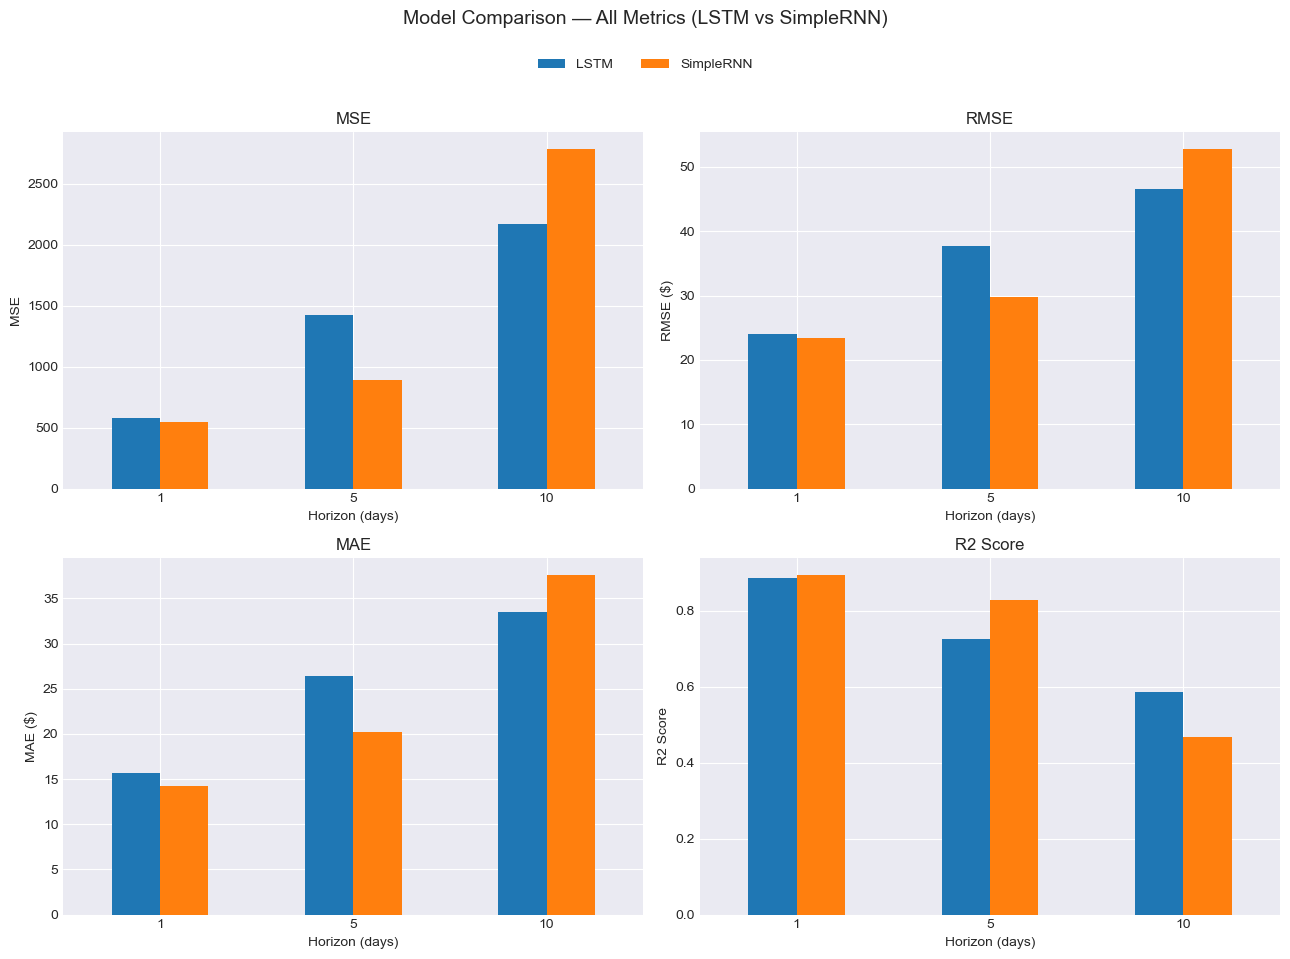

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

metrics = ["MSE", "RMSE", "MAE", "R2 Score"]
ylabels = ["MSE", "RMSE ($)", "MAE ($)", "R2 Score"]

for ax, metric, ylabel in zip(axes.flat, metrics, ylabels):
    pivot = comparison.pivot(
        index="Horizon (days)",
        columns="Model",
        values=metric
    )

    pivot.plot(kind="bar", ax=ax, legend=False)

    ax.set_title(metric)
    ax.set_xlabel("Horizon (days)")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=0)

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    bbox_to_anchor=(0.5, 1.02)
)

fig.suptitle(
    "Model Comparison — All Metrics (LSTM vs SimpleRNN)",
    y=1.06,
    fontsize=14
)

plt.tight_layout()
plt.show()

##  Section 16: 10-Day Forward Recursive Forecast


10-Day Forward Recursive Forecast
Tuned LSTM vs Tuned SimpleRNN
Day  1 | LSTM: $630.26 | SimpleRNN: $636.47
Day  2 | LSTM: $642.93 | SimpleRNN: $604.32
Day  3 | LSTM: $643.85 | SimpleRNN: $544.30
Day  4 | LSTM: $637.37 | SimpleRNN: $531.74
Day  5 | LSTM: $626.37 | SimpleRNN: $490.48
Day  6 | LSTM: $612.70 | SimpleRNN: $464.91
Day  7 | LSTM: $597.63 | SimpleRNN: $424.59
Day  8 | LSTM: $582.03 | SimpleRNN: $404.85
Day  9 | LSTM: $566.49 | SimpleRNN: $383.66
Day 10 | LSTM: $551.45 | SimpleRNN: $349.05


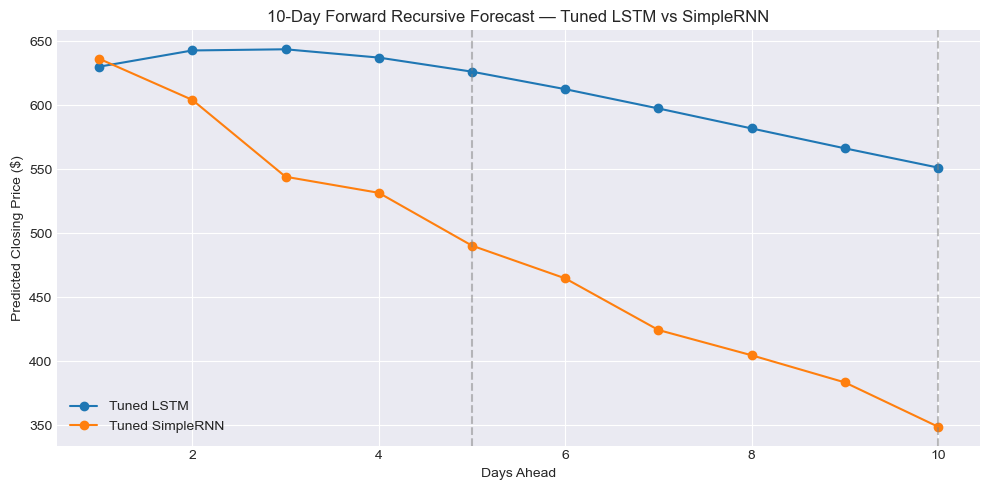

In [35]:
# ============================================================
# Section 16: 10-Day Forward Recursive Forecast
# Final Tuned LSTM vs SimpleRNN
# ============================================================

from tensorflow.keras.models import load_model
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Load BEST TUNED 1-Day Models from Section 14
# ------------------------------------------------------------

best_lstm_h1 = load_model("best_LSTM_h1_tuned.keras")
best_rnn_h1 = load_model("best_SimpleRNN_h1_tuned.keras")


# ------------------------------------------------------------
# Last WINDOW observations from the complete dataset
# ------------------------------------------------------------

last_window = scaler.transform(
    df[["Close"]].values
)[-WINDOW:].reshape(1, WINDOW, 1)


# ------------------------------------------------------------
# Recursive forecast function
# ------------------------------------------------------------

def recursive_forecast(model, last_window, days=10):

    current_window = last_window.copy()
    future_scaled = []

    for _ in range(days):

        prediction = model.predict(
            current_window,
            verbose=0
        )

        predicted_value = prediction[0, 0]

        future_scaled.append(predicted_value)

        current_window = np.append(
            current_window[:, 1:, :],
            prediction.reshape(1, 1, 1),
            axis=1
        )

    return scaler.inverse_transform(
        np.array(future_scaled).reshape(-1, 1)
    )


# ------------------------------------------------------------
# Generate 10-Day Forecasts
# ------------------------------------------------------------

future_prices_lstm = recursive_forecast(
    best_lstm_h1,
    last_window,
    days=10
)

future_prices_rnn = recursive_forecast(
    best_rnn_h1,
    last_window,
    days=10
)


# ------------------------------------------------------------
# Print Forecast Values
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("10-Day Forward Recursive Forecast")
print("Tuned LSTM vs Tuned SimpleRNN")
print("=" * 60)

for day in range(10):

    print(
        f"Day {day+1:2d} | "
        f"LSTM: ${future_prices_lstm[day,0]:.2f} | "
        f"SimpleRNN: ${future_prices_rnn[day,0]:.2f}"
    )


# ------------------------------------------------------------
# Plot Forecast
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    range(1, 11),
    future_prices_lstm.flatten(),
    marker="o",
    label="Tuned LSTM"
)

plt.plot(
    range(1, 11),
    future_prices_rnn.flatten(),
    marker="o",
    label="Tuned SimpleRNN"
)

plt.axvline(
    5,
    color="gray",
    linestyle="--",
    alpha=0.5
)

plt.axvline(
    10,
    color="gray",
    linestyle="--",
    alpha=0.5
)

plt.title(
    "10-Day Forward Recursive Forecast — Tuned LSTM vs SimpleRNN"
)

plt.xlabel("Days Ahead")
plt.ylabel("Predicted Closing Price ($)")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Section 17: NLP — News Sentiment Analysis

Sample headlines dataset:


,Date,Headline
0,2013-05-09,"Tesla posts surprise first quarterly profit, s..."
1,2013-08-05,Tesla shares tumble after quarterly loss widens
2,2014-02-20,Tesla to build massive battery Gigafactory
3,2014-10-01,Tesla unveils Autopilot hardware for Model S
4,2016-05-04,Tesla posts wider-than-expected quarterly loss
5,2016-08-01,Tesla to acquire SolarCity in controversial deal
6,2017-04-03,Tesla passes Ford in market value amid deliver...
7,2018-04-05,Tesla recalls thousands of Model X SUVs over s...
8,2018-08-07,"Musk says considering taking Tesla private, st..."
9,2018-10-24,"Tesla posts record profit, shares surge on str..."



Cleaned Headlines:


,Headline,Clean_Headline
0,"Tesla posts surprise first quarterly profit, s...",tesla posts surprise first quarterly profit sh...
1,Tesla shares tumble after quarterly loss widens,tesla shares tumble after quarterly loss widens
2,Tesla to build massive battery Gigafactory,tesla to build massive battery gigafactory
3,Tesla unveils Autopilot hardware for Model S,tesla unveils autopilot hardware for model s
4,Tesla posts wider-than-expected quarterly loss,tesla posts widerthanexpected quarterly loss
5,Tesla to acquire SolarCity in controversial deal,tesla to acquire solarcity in controversial deal
6,Tesla passes Ford in market value amid deliver...,tesla passes ford in market value amid deliver...
7,Tesla recalls thousands of Model X SUVs over s...,tesla recalls thousands of model x suvs over s...
8,"Musk says considering taking Tesla private, st...",musk says considering taking tesla private sto...
9,"Tesla posts record profit, shares surge on str...",tesla posts record profit shares surge on stro...



Sentiment Analysis Results:


,Date,Headline,Sentiment_Score,Sentiment_Label
0,2013-05-09,"Tesla posts surprise first quarterly profit, s...",0.7351,Positive
1,2013-08-05,Tesla shares tumble after quarterly loss widens,-0.0258,Neutral
2,2014-02-20,Tesla to build massive battery Gigafactory,0.0000,Neutral
3,2014-10-01,Tesla unveils Autopilot hardware for Model S,0.0000,Neutral
4,2016-05-04,Tesla posts wider-than-expected quarterly loss,-0.3182,Negative
5,2016-08-01,Tesla to acquire SolarCity in controversial deal,-0.2023,Negative
6,2017-04-03,Tesla passes Ford in market value amid deliver...,0.6124,Positive
7,2018-04-05,Tesla recalls thousands of Model X SUVs over s...,0.0000,Neutral
8,2018-08-07,"Musk says considering taking Tesla private, st...",0.0000,Neutral
9,2018-10-24,"Tesla posts record profit, shares surge on str...",0.8126,Positive


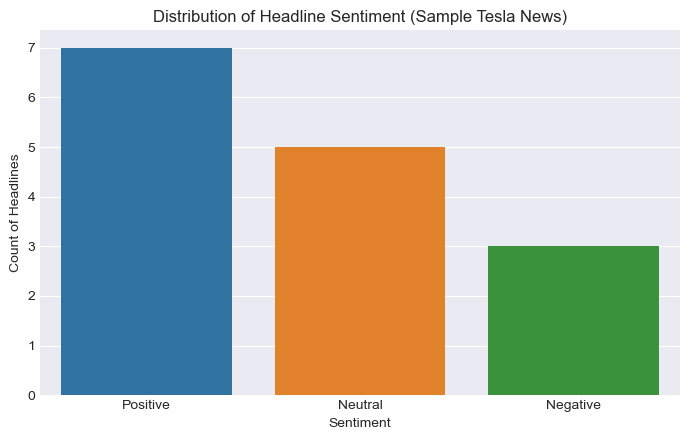


News Sentiment and Same-Day Stock Return:


,Date,Sentiment_Score,Sentiment_Label,Daily_Return
0,2013-05-09,0.7351,Positive,24.395054
1,2013-08-05,-0.0258,Neutral,4.840575
2,2014-02-20,0.0000,Neutral,8.433176
3,2014-10-01,0.0000,Neutral,-1.005434
4,2016-05-04,-0.3182,Negative,-4.201106
5,2016-08-01,-0.2023,Negative,-2.035861
6,2017-04-03,0.6124,Positive,7.265541
7,2018-04-05,0.0000,Neutral,6.544922
8,2018-08-07,0.0000,Neutral,10.988631
9,2018-10-24,0.8126,Positive,-1.917459


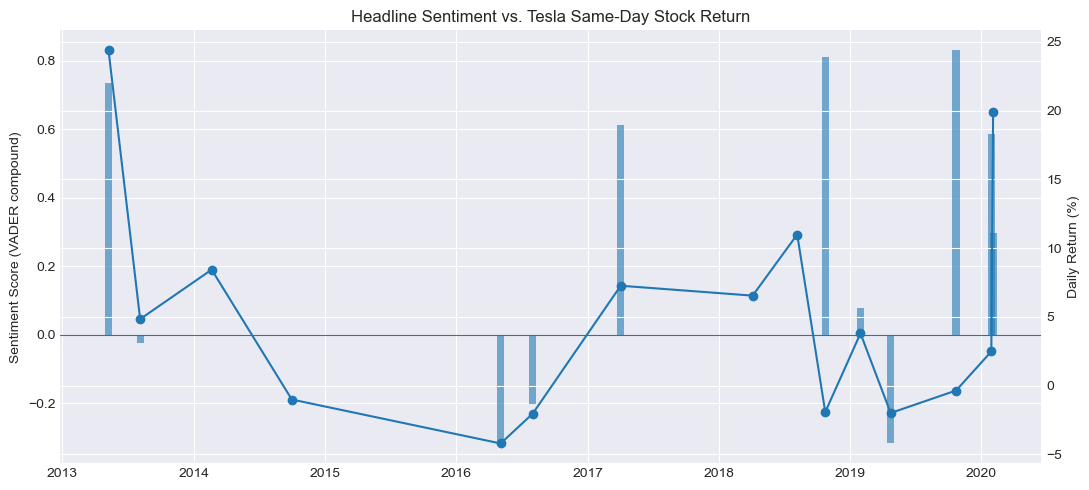


Correlation between headline sentiment and same-day stock return: 0.309

Section 17 Summary
News sentiment analysis was performed using VADER on a sample of Tesla headlines.
The analysis compares headline sentiment with same-day Tesla stock returns.
This NLP analysis is treated as an additional feature-engineering / exploratory component and is not used as an input feature in the final SimpleRNN/LSTM forecasting models.


In [36]:
# ============================================================
# Section 17: NLP — News Sentiment Analysis
# ============================================================

import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer


# ------------------------------------------------------------
# 1. Create Daily Return
# ------------------------------------------------------------

if "Daily_Return" not in df.columns:
    df["Daily_Return"] = df["Close"].pct_change() * 100


# ------------------------------------------------------------
# 2. Sample Tesla News Headlines
# ------------------------------------------------------------

headlines = pd.DataFrame([
    ("2013-05-09", "Tesla posts surprise first quarterly profit, shares soar"),
    ("2013-08-05", "Tesla shares tumble after quarterly loss widens"),
    ("2014-02-20", "Tesla to build massive battery Gigafactory"),
    ("2014-10-01", "Tesla unveils Autopilot hardware for Model S"),
    ("2016-05-04", "Tesla posts wider-than-expected quarterly loss"),
    ("2016-08-01", "Tesla to acquire SolarCity in controversial deal"),
    ("2017-04-03", "Tesla passes Ford in market value amid delivery growth"),
    ("2018-04-05", "Tesla recalls thousands of Model X SUVs over steering flaw"),
    ("2018-08-07", "Musk says considering taking Tesla private, stock jumps"),
    ("2018-10-24", "Tesla posts record profit, shares surge on strong deliveries"),
    ("2019-01-30", "Tesla misses delivery targets, shares fall sharply"),
    ("2019-04-24", "Tesla reports steep quarterly loss, cash concerns weigh on stock"),
    ("2019-10-23", "Tesla surprises with profit, shares rally on strong China demand"),
    ("2020-01-29", "Tesla posts fifth straight profitable quarter, stock rallies"),
    ("2020-02-03", "Tesla shares surge to record high amid short squeeze")
], columns=["Date", "Headline"])


headlines["Date"] = pd.to_datetime(headlines["Date"])

print("Sample headlines dataset:")
display(headlines)


# ------------------------------------------------------------
# 3. Text Cleaning
# ------------------------------------------------------------

def clean_text(text):

    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text


headlines["Clean_Headline"] = headlines["Headline"].apply(clean_text)

print("\nCleaned Headlines:")
display(
    headlines[["Headline", "Clean_Headline"]]
)


# ------------------------------------------------------------
# 4. VADER Sentiment Analysis
# ------------------------------------------------------------

analyzer = SentimentIntensityAnalyzer()


def get_sentiment(text):

    scores = analyzer.polarity_scores(text)

    compound = scores["compound"]

    if compound >= 0.05:
        label = "Positive"

    elif compound <= -0.05:
        label = "Negative"

    else:
        label = "Neutral"

    return pd.Series([compound, label])


headlines[
    ["Sentiment_Score", "Sentiment_Label"]
] = headlines["Clean_Headline"].apply(get_sentiment)


print("\nSentiment Analysis Results:")

display(
    headlines[
        [
            "Date",
            "Headline",
            "Sentiment_Score",
            "Sentiment_Label"
        ]
    ]
)


# ------------------------------------------------------------
# 5. Sentiment Distribution
# ------------------------------------------------------------

plt.figure(figsize=(7, 4.5))

order = ["Positive", "Neutral", "Negative"]

sns.countplot(
    data=headlines,
    x="Sentiment_Label",
    order=order,
    hue="Sentiment_Label",
    hue_order=order,
    legend=False
)

plt.title("Distribution of Headline Sentiment (Sample Tesla News)")
plt.xlabel("Sentiment")
plt.ylabel("Count of Headlines")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. Merge News with Same-Day Stock Return
# ------------------------------------------------------------

stock_returns = (
    df[["Daily_Return"]]
    .reset_index()[["Date", "Daily_Return"]]
)

stock_returns["Date"] = pd.to_datetime(
    stock_returns["Date"]
)


merged = pd.merge(
    headlines,
    stock_returns,
    on="Date",
    how="inner"
)


print("\nNews Sentiment and Same-Day Stock Return:")
display(
    merged[
        [
            "Date",
            "Sentiment_Score",
            "Sentiment_Label",
            "Daily_Return"
        ]
    ]
)


# ------------------------------------------------------------
# 7. Sentiment vs Stock Return Visualization
# ------------------------------------------------------------

fig, ax1 = plt.subplots(figsize=(11, 5))


ax1.bar(
    merged["Date"],
    merged["Sentiment_Score"],
    alpha=0.6,
    width=20,
    label="Headline Sentiment Score"
)

ax1.set_ylabel(
    "Sentiment Score (VADER compound)"
)

ax1.axhline(
    0,
    linewidth=0.8
)


ax2 = ax1.twinx()

ax2.plot(
    merged["Date"],
    merged["Daily_Return"],
    marker="o",
    label="Same-day Stock Return (%)"
)

ax2.set_ylabel(
    "Daily Return (%)"
)


plt.title(
    "Headline Sentiment vs. Tesla Same-Day Stock Return"
)

fig.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. Correlation Analysis
# ------------------------------------------------------------

corr = merged[
    "Sentiment_Score"
].corr(
    merged["Daily_Return"]
)

print(
    f"\nCorrelation between headline sentiment "
    f"and same-day stock return: {corr:.3f}"
)


# ------------------------------------------------------------
# 9. Section 17 Conclusion
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("Section 17 Summary")
print("=" * 60)

print(
    "News sentiment analysis was performed using VADER "
    "on a sample of Tesla headlines."
)

print(
    "The analysis compares headline sentiment with "
    "same-day Tesla stock returns."
)

print(
    "This NLP analysis is treated as an additional "
    "feature-engineering / exploratory component and "
    "is not used as an input feature in the final "
    "SimpleRNN/LSTM forecasting models."
)

## Section 18: Insights, Conclusion & Business Use Cases

### Insights & Conclusion

- Forecasting became harder as the prediction horizon increased.
- SimpleRNN performed best for 1-day and 5-day forecasting, while LSTM performed best for 10-day forecasting.
- Hyperparameter tuning improved 4 of the 6 model-horizon combinations.
- The final best models were:
  - **1-Day:** Tuned SimpleRNN
  - **5-Day:** Baseline SimpleRNN
  - **10-Day:** Baseline LSTM
- Recursive forecasting showed that prediction errors can accumulate over multiple forecasting steps.
- The NLP analysis showed a modest positive correlation (**0.309**) between headline sentiment and same-day Tesla returns.
- Since the NLP analysis used only 15 sample headlines, the result should be treated as exploratory rather than causal.

### Business Use Cases

#### 1. Stock Market Trading & Investment Strategies

- **Automated Trading:** Model predictions can support algorithmic trading strategies and buying/selling decisions based on predicted price trends.
- **Risk Management & Portfolio Optimization:** Investors can use predicted price movements to adjust portfolio allocations and assess potential risks.

#### 2. Financial Forecasting & Time-Series Analysis

- **Long-Term Investment Planning:** Stock-price forecasts can support data-driven investment decisions for retirement funds, ETFs, and mutual funds.
- **Macroeconomic Analysis:** Tesla's stock trends can be compared with interest rates, inflation, and industry trends.

#### 3. Business & Corporate Use Cases

- **Company Valuation & Earnings Prediction:** Similar predictive models can be used to forecast revenue and profit trends for financial planning and investor guidance.
- **Competitor Analysis:** The approach can be applied to companies such as Rivian, NIO, and Lucid Motors to compare their stock-price trends with Tesla.

#### 4. Deep Learning & Research Use Cases

- **Time-Series Model Comparison:** The project can be extended by comparing SimpleRNN and LSTM with GRU, Transformer, or ARIMA models.
- **Feature Engineering & Alternative Data:** Future models can incorporate news sentiment, social-media trends, trading volume, and macroeconomic indicators to improve forecasting.